# Bifurcaciones de Hopf degeneradas


# Bifurcacion de Hopf Supercritica

En este tipo de bifurcaciones, tenemos un punto de equilibrio del cual surge un ciclo limite

## Forma normal

$$
\begin{cases}
\dot x = \mu x - y - x(x^2 + y^2), \\
\dot y = x + \mu y - y(x^2 + y^2).
\end{cases}
$$

El punto $(0,0)$ es solución de equilibrio y además:

El Jacobiano del sistema es
$$
J =
\begin{pmatrix}
\mu - 3x^2 - y^2 & -1 - 2xy \\
1 - 2xy & \mu - 3y^2 - x^2
\end{pmatrix}.
$$

Evaluando en el origen:
$$
J_0 =
\begin{pmatrix}
\mu & -1 \\
1 & \mu
\end{pmatrix}.
$$

Su determinante es
$$
\det(J_0) = \mu^2 + 1 > 0,
$$
y su traza es
$$
\operatorname{Tr}(J_0) = 2\mu.
$$

Por lo tanto, los valores propios satisfacen
$$
\lambda_{1,2}
= \frac{2\mu \pm \sqrt{4\mu^2 - 4(\mu^2 + 1)}}{2}
= \mu \pm i.
$$

Así, hay una **bifurcación de Hopf** en
$$
\mu = 0.
$$


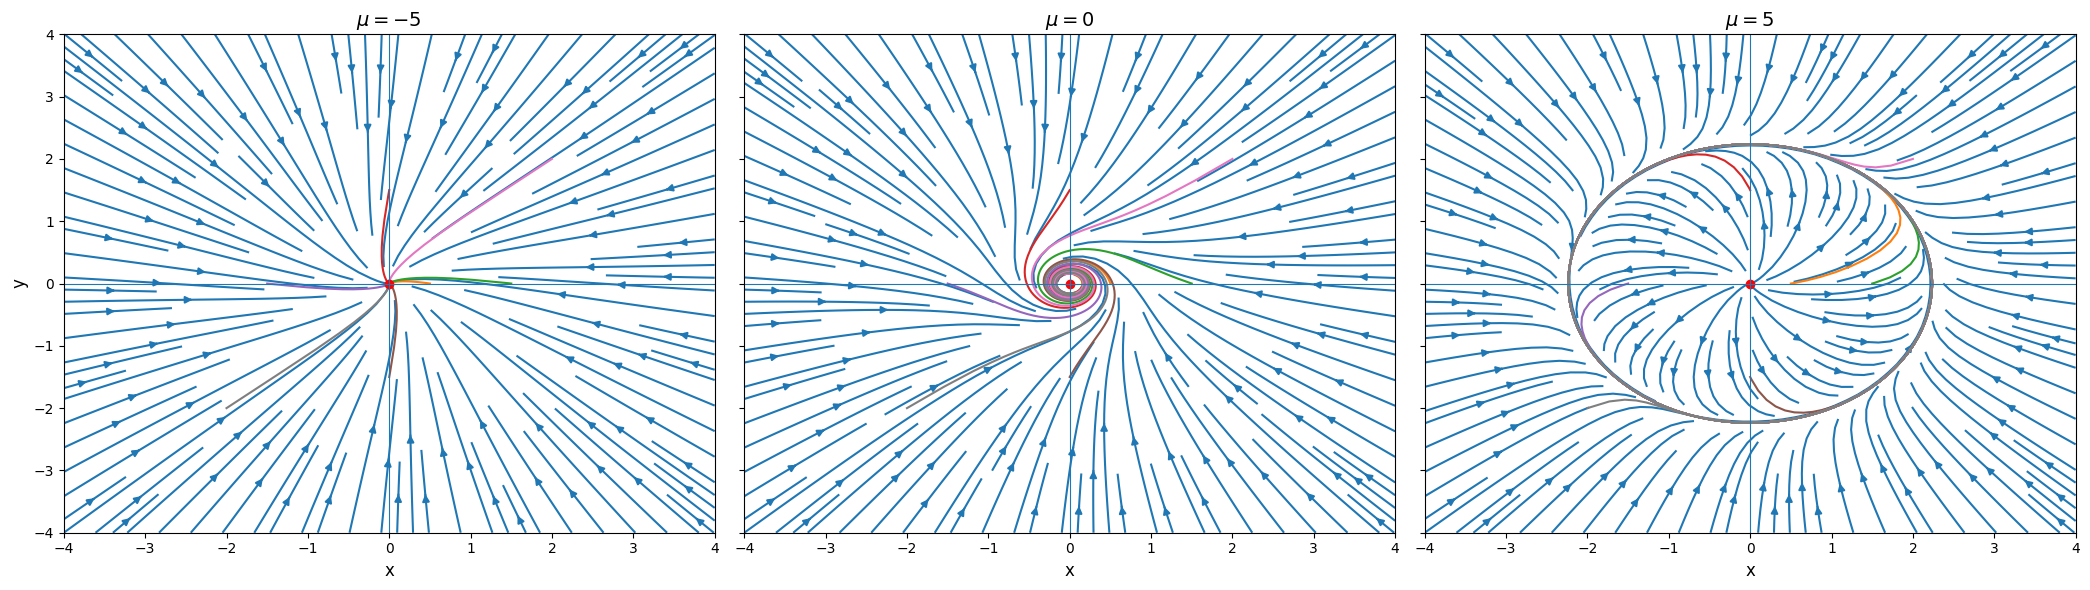

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema de Hopf supercrítico
def sistema(t, z, mu):
    x, y = z
    r2 = x**2 + y**2
    dx = mu*x - y - x*r2
    dy = x + mu*y - y*r2
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-4, 4, 30)
y = np.linspace(-4, 4, 30)
X, Y = np.meshgrid(x, y)

mus = [-5, 0, 5]

# 👉 FIGURA MÁS GRANDE
fig, axes = plt.subplots(
    1, 3,
    figsize=(21, 6),   # ← aquí está el cambio clave
    sharex=True,
    sharey=True
)

for ax, mu in zip(axes, mus):

    U = mu*X - Y - X*(X**2 + Y**2)
    V = X + mu*Y - Y*(X**2 + Y**2)

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.4)

    # Trayectorias
    condiciones_iniciales = [
        [0.5, 0], [1.5, 0], [0, 1.5],
        [-1.5, 0], [0, -1.5],
        [2, 2], [-2, -2]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 20],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1], linewidth=1.5)

    # Punto de equilibrio
    ax.plot(0, 0, 'ro', markersize=6)

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$", fontsize=14)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_xlabel("x", fontsize=12)

axes[0].set_ylabel("y", fontsize=12)

plt.tight_layout()
plt.show()


Ahora, si hacemos
$$
r^2 = x^2 + y^2,
$$
entonces
$$
2r\dot r = 2x\dot x + 2y\dot y.
$$

Por lo tanto,
$$
r\dot r = x\dot x + y\dot y.
$$

Sustituyendo el sistema
$$
\begin{cases}
\dot x = \mu x - y - x(x^2 + y^2), \\
\dot y = x + \mu y - y(x^2 + y^2),
\end{cases}
$$

obtenemos
$$
\begin{aligned}
r\dot r
&= x\big(\mu x - y - x(x^2+y^2)\big)
  + y\big(x + \mu y - y(x^2+y^2)\big)= \\
&= \mu(x^2+y^2) - (x^2+y^2)^2=\mu r^2 - r^4
\end{aligned}
$$

Es decir
$$
r\dot r = \mu r^2 - r^4,
$$
y, para $r \neq 0$,
$$
\dot r = \mu r - r^3.
$$

Esta es la **forma normal de la bifurcación de tridente supercrítica**.

---

Para $\mu < 0$ solo hay un punto de equilibrio $r=0$.

Para $\mu > 0$ hay tres soluciones de equilibrio:
$$
r = 0, \qquad r = \pm\sqrt{\mu}.
$$

Como $r \ge 0$, nos interesa
$$
r = \sqrt{\mu}.
$$


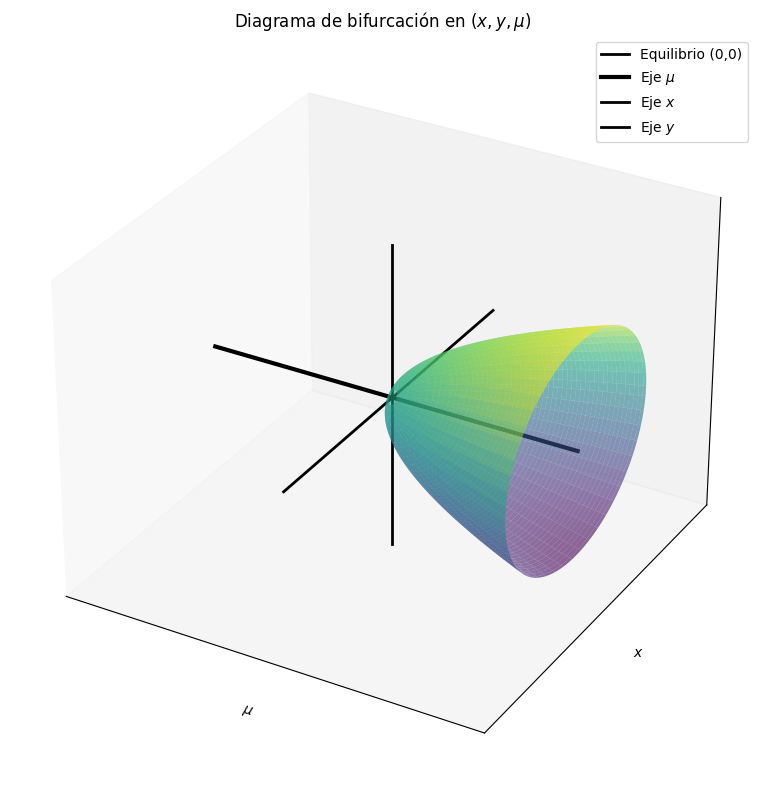

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Parámetro mu
mu_vals = np.linspace(-2, 2, 300)

# Equilibrio trivial (0,0)
x0 = np.zeros_like(mu_vals)
y0 = np.zeros_like(mu_vals)

# Ciclo límite para mu > 0
mu_pos = mu_vals[mu_vals > 0]
theta = np.linspace(0, 2*np.pi, 200)

MU, TH = np.meshgrid(mu_pos, theta)
R = np.sqrt(MU)

X = R * np.cos(TH)
Y = R * np.sin(TH)
MU_surface = MU

# Gráfica
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')
ax.grid(False)


# Rama trivial
ax.plot(mu_vals, x0, y0, 'k', linewidth=2, label='Equilibrio (0,0)')

# Superficie del ciclo límite
ax.plot_surface(
    MU_surface, X, Y,
    alpha=0.6,
    cmap='viridis',
    edgecolor='none'
)

# Eje mu: x = 0, y = 0
ax.plot(mu_vals, 0*mu_vals, 0*mu_vals,
        color='black', linewidth=3, label=r'Eje $\mu$')

# Eje x: mu = 0, y = 0
ax.plot(0*mu_vals, mu_vals, 0*mu_vals,
        color='black', linewidth=2, label=r'Eje $x$')

# Eje y: mu = 0, x = 0
ax.plot(0*mu_vals, 0*mu_vals, mu_vals,
        color='black', linewidth=2, label=r'Eje $y$')

# Etiquetas
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$x$')
ax.set_zlabel(r'$y$')
ax.set_title('Diagrama de bifurcación en $(x,y,\\mu)$')

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.legend()
plt.tight_layout()
plt.show()


## Bifurcacion de Hopf Subcritica

Su forma normal es:

$$
\begin{cases}
\dot{x} = \mu x - y + x(x^2 + y^2), \\
\dot{y} = x + \mu y + y(x^2 + y^2).
\end{cases}
$$

Definimos

$$
r^2 = x^2 + y^2.
$$

Entonces,

$$
\dot{r} = \mu r + r^3.
$$

De donde se obtiene que

$$
r = \pm \sqrt{-\mu}.
$$

y para $\mu > 0$ no hay soluciones de equilibrio.

Como el procedimiento es el mismo para obtener los eigenvalores,
se concluye el comportamiento tipo Hopf subcrítico.


### Ejemplo

Consideremos el sistema

$$
\begin{cases}
\dot{x} = y, \\
\dot{y} = -\mu y - \sin x.
\end{cases}
$$

donde $(0,0)$ es una solución de equilibrio.

El Jacobiano del sistema es

$$
J =
\begin{pmatrix}
0 & 1 \\
-\cos x & -\mu
\end{pmatrix},
$$

y evaluado en el equilibrio $(0,0)$ se obtiene

$$
J_0 =
\begin{pmatrix}
0 & 1 \\
-1 & -\mu
\end{pmatrix}.
$$

Por lo tanto,

$$
\det J_0 = 1,
\qquad
\operatorname{Tr} J_0 = -\mu.
$$

Además, los valores propios están dados por

$$
\lambda
= \frac{-\mu \pm \sqrt{\mu^2 - 4}}{2}.
$$

Si

$$
\mu^2 - 4 \ge 0,
$$

los valores propios son reales.

En particular, para $\mu = 0$ se tiene

$$
\lambda = \pm i,
$$

y los valores propios cruzan el eje imaginario.


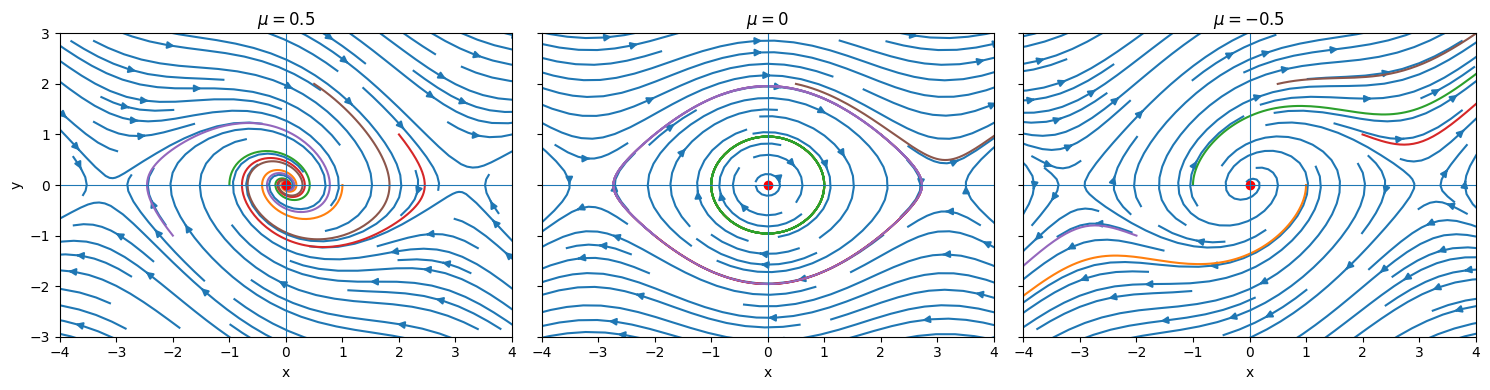

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    return [y, -mu*y - np.sin(x)]

# Mallado del espacio fase
x = np.linspace(-2*np.pi, 2*np.pi, 25)
y = np.linspace(-4, 4, 25)
X, Y = np.meshgrid(x, y)

mus = [0.5, 0, -0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = Y
    V = -mu*Y - np.sin(X)

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [1, 0], [-1, 0], [2, 1], [-2, -1], [0.5, 2]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 20],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Punto de equilibrio
    ax.plot(0, 0, 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlabel("x")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()


### Ejemplo

Consideremos el sistema

$$
\begin{cases}
\dot{x} = \mu x - y + x y^2, \\
\dot{y} = x + \mu y + y^3,
\end{cases}
$$

con $(0,0)$ como solución de equilibrio.

Hagamos el cambio de variable $$r^2 = x^2 + y^2$$

y deribando, por regla de la cadena temos que: 

$$
2r\dot r = 2x\dot x + 2y\dot y$$

Es decir

$$
r\dot r =
x\dot{x} + y\dot{y}
= x(\mu x - y + x y^2) + y(x + \mu y + y^3)=
$$

$$
= \mu(x^2 + y^2) + x^2 y^2 + y^4
= \mu r^2 + y^2 r^2
$$

$$
= r^2(\mu + y^2),
$$

por lo tanto

$$
r\dot r = r^2(\mu + y^2)
$$

y como $r>0$ 

$$
\dot r = r(\mu + y^2)
$$

El Jacobiano del sistema es

$$
J =
\begin{pmatrix}
\mu + y^2 & -1 + 2xy \\
1 & \mu + 3y^2
\end{pmatrix}.
$$

Evaluado en el equilibrio $(0,0)$ se obtiene

$$
J_0 =
\begin{pmatrix}
\mu & -1 \\
1 & \mu
\end{pmatrix}.
$$

Por lo tanto,

$$
\det J = \mu^2 + 1,
\qquad
\operatorname{Tr} J = 2\mu.
$$

Los valores propios son

$$
\lambda_{1,2} = \mu \pm i.
$$

lo cual nos dice que hay espirales, pero nos gustaria ver como se comporta el sistema cuando variamos $\mu$

Notemos primero que 
$$
\dot r = r\mu + ry^2 \geq r\mu \geq 0
$$

De donde, si

$$
\dot r = \mu r \quad\text{entonces}\quad r(t) = C_0 e^{\mu t}
$$

y esto nos dice que: $r(t) \to +\infty$ cuando $t \to +\infty$, entonces $\dot r \to +\infty$.

Es decir, para $\mu > 0$ **no hay ciclos límite**.

Y para $\mu = 0$ se tiene

$$
\dot r = r y^2 \ge 0,
$$

y por lo tanto el equilibrio **sigue siendo inestable**.

En consecuencia, **hay una bifurcación subcrítica**.


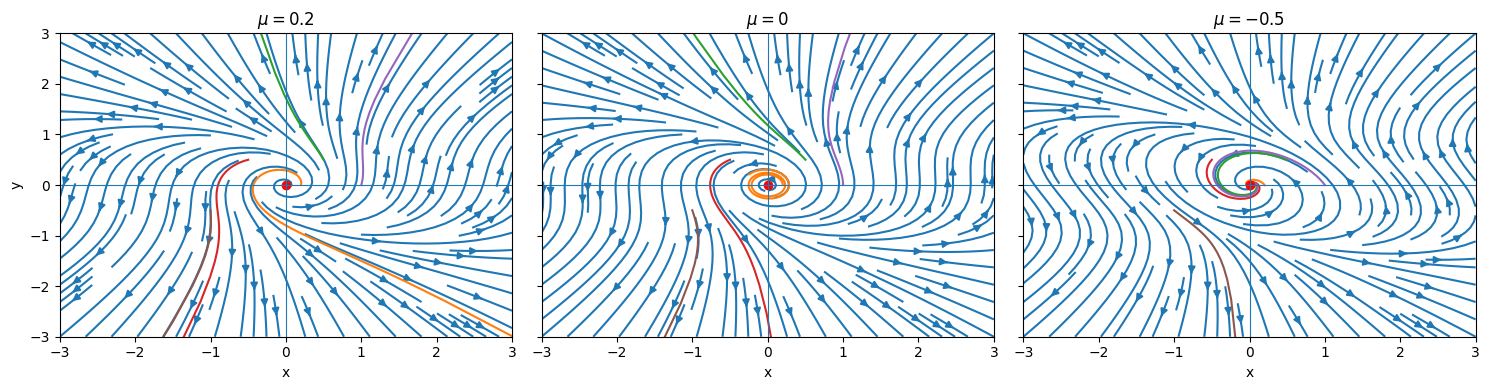

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Sistema
def sistema(t, z, mu):
    x, y = z
    dx = mu*x - y + x*y**2
    dy = x + mu*y + y**3
    return [dx, dy]

# Mallado del espacio fase
x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)

mus = [0.2, 0, -0.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, mu in zip(axes, mus):

    U = mu*X - Y + X*Y**2
    V = X + mu*Y + Y**3

    # Campo de direcciones
    ax.streamplot(X, Y, U, V, density=1.2)

    # Trayectorias
    condiciones_iniciales = [
        [0.2, 0],
        [0.5, 0.5],
        [-0.5, 0.5],
        [1, 0],
        [-1, -0.5]
    ]

    for z0 in condiciones_iniciales:
        sol = solve_ivp(
            sistema,
            [0, 15],
            z0,
            args=(mu,),
            max_step=0.05
        )
        ax.plot(sol.y[0], sol.y[1])

    # Punto de equilibrio
    ax.plot(0, 0, 'ro')

    ax.axhline(0, linewidth=0.8)
    ax.axvline(0, linewidth=0.8)

    ax.set_title(rf"$\mu = {mu}$")
    ax.set_xlabel("x")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)

axes[0].set_ylabel("y")

plt.tight_layout()
plt.show()
